# Crohn's Disease Microbiome — Exploratory Data Analysis

**Project:** crohns-microbiome-ml  
**Dataset:** HMP2 / iHMP (Human Microbiome Project 2 — IBD cohort)  
**Goal:** Explore the OTU abundance table and metadata to understand the dataset before modeling.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [5]:
metadata = pd.read_csv('/Users/liamcampbell/Desktop/crohns-microbiome-ml/data/hmp2_metadata_2018-08-20.csv', low_memory=False)
otuTable = pd.read_csv('/Users/liamcampbell/Desktop/crohns-microbiome-ml/data/taxonomic_profiles.tsv.gz', sep= '\t', index_col=0)


print(metadata.shape, otuTable.shape)

meta_16S = metadata[metadata['data_type'].str.contains('16S', na=False)]
print(meta_16S['diagnosis'].value_counts())

print('CD = Crohns Disease')
print('UC = Ulcerative Colitis')
print('nonIBD = Healthy Controls')


(5533, 490) (982, 179)
diagnosis
CD        211
UC         89
nonIBD     58
Name: count, dtype: int64
CD = Crohns Disease
UC = Ulcerative Colitis
nonIBD = Healthy Controls


In [6]:
# Join OTU table with diagnosis labels
# OTU table: rows=taxa, cols=samples — transpose so rows=samples
otu_t = otuTable.T  # now (179, 982)
otu_t.index.name = 'External ID'

# Join on External ID
meta_16s = metadata[metadata['data_type'].str.contains('16S', na=False)]
otu_meta = otu_t.join(meta_16s.set_index('External ID')[['diagnosis', 'week_num', 'Participant ID']], how='inner')

print("Joined shape:", otu_meta.shape)
print(otu_meta['diagnosis'].value_counts())

Joined shape: (178, 985)
diagnosis
CD        86
nonIBD    46
UC        46
Name: count, dtype: int64


In [7]:
# Q1: Samples per group
print("Total samples:", len(otu_meta))
print(otu_meta['diagnosis'].value_counts())

# Q2: Number of bacterial taxa
n_taxa = otuTable.shape[0]
print("\nNumber of taxa:", n_taxa)

# Q3: Sparsity (% zeros)
otu_only = otu_meta.iloc[:, :982]  # just the OTU columns
sparsity = (otu_only == 0).sum().sum() / otu_only.size * 100
print(f"\nSparsity: {sparsity:.1f}% zeros")

# Q4: Top 10 most abundant taxa
top10 = otu_only.sum().sort_values(ascending=False).head(10)
print("\nTop 10 taxa:\n", top10)

# Q5: Samples with very few reads (potential quality issues)
read_counts = otu_only.sum(axis=1)
print("\nRead counts per sample:")
print(read_counts.describe())
low_quality = read_counts[read_counts < read_counts.quantile(0.05)]
print(f"\nPotential low-quality samples (<5th percentile): {len(low_quality)}")

Total samples: 178
diagnosis
CD        86
nonIBD    46
UC        46
Name: count, dtype: int64

Number of taxa: 982

Sparsity: 91.7% zeros

Top 10 taxa:
 Unc05bd1    436194.0
Unc64172    409198.0
Unc054vi    294448.0
Unc91005    111388.0
UncG3786    109438.0
UncO8895     75291.0
Unc01pk4     47133.0
Unc00y95     46903.0
UncC1868     44063.0
Unc69508     41982.0
dtype: object

Read counts per sample:
count       178.0
unique      178.0
top       23607.0
freq          1.0
dtype: float64

Potential low-quality samples (<5th percentile): 9


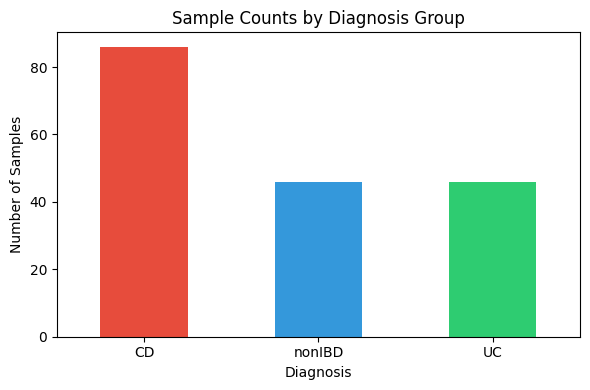

In [8]:
# Bar chart of sample counts by diagnosis
fig, ax = plt.subplots(figsize=(6, 4))
otu_meta['diagnosis'].value_counts().plot(kind='bar', ax=ax, color=['#e74c3c','#3498db','#2ecc71'])
ax.set_title('Sample Counts by Diagnosis Group')
ax.set_xlabel('Diagnosis')
ax.set_ylabel('Number of Samples')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('../figures/sample_counts_by_diagnosis.png', dpi=150)
plt.show()